# Multimodal Fine-Tuning with Small Language Models

This project fine-tunes a small vision-language model to generate captions
for mobile application screenshots.

The goal is to explore multimodal fine-tuning using small language models.

In [1]:
!pip install -q transformers datasets peft accelerate bitsandbytes evaluate pillow huggingface_hub

In [2]:
import torch
from datasets import load_dataset
from transformers import (
    BlipProcessor,
    BlipForConditionalGeneration,
    TrainingArguments,
    Trainer
)
from peft import LoraConfig, get_peft_model

In [3]:
from huggingface_hub import notebook_login
notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


## Dataset

We use the RICO-Screen2Words dataset, which contains mobile UI screenshots
paired with natural language captions describing the screen content.

Each sample contains:
- image: screenshot of a mobile application UI
- captions: textual descriptions of the screen

This dataset is suitable for multimodal learning because it aligns
visual interface layouts with semantic descriptions.

In [4]:
dataset = load_dataset("rootsautomation/RICO-Screen2Words")

dataset

DatasetDict({
    train: Dataset({
        features: ['screenId', 'captions', 'file_name', 'app_package_name', 'play_store_name', 'category', 'average_rating', 'number_of_ratings', 'number_of_downloads', 'file_name_icon', 'file_name_semantic', 'semantic_annotations', 'view_hierarchy', 'image', 'image_icon', 'image_semantic'],
        num_rows: 15743
    })
    val: Dataset({
        features: ['screenId', 'captions', 'file_name', 'app_package_name', 'play_store_name', 'category', 'average_rating', 'number_of_ratings', 'number_of_downloads', 'file_name_icon', 'file_name_semantic', 'semantic_annotations', 'view_hierarchy', 'image', 'image_icon', 'image_semantic'],
        num_rows: 2364
    })
    test: Dataset({
        features: ['screenId', 'captions', 'file_name', 'app_package_name', 'play_store_name', 'category', 'average_rating', 'number_of_ratings', 'number_of_downloads', 'file_name_icon', 'file_name_semantic', 'semantic_annotations', 'view_hierarchy', 'image', 'image_icon', 'imag

In [5]:
dataset = dataset["train"].train_test_split(test_size=0.1)

train_dataset = dataset["train"]
test_dataset = dataset["test"]

## Model Selection

We use the BLIP (Bootstrapped Language Image Pretraining) model
for image captioning.

Reasons for choosing BLIP:
- Lightweight architecture suitable for T4 GPUs
- Strong performance on vision-language tasks
- Native support for image captioning
- Available through Hugging Face Transformers

In [6]:
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")

model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
)

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

In [7]:
def preprocess(example):
    caption = example["captions"][0]

    inputs = processor(
        images=example["image"],
        text=caption,
        padding="max_length",
        truncation=True,
        return_tensors="pt"
    )

    inputs = {k: v.squeeze(0) for k, v in inputs.items()}

    inputs["labels"] = inputs["input_ids"]

    return inputs

In [8]:
train_dataset = train_dataset.map(
    preprocess,
    remove_columns=train_dataset.column_names
)

test_dataset = test_dataset.map(
    preprocess,
    remove_columns=test_dataset.column_names
)

train_dataset.set_format(type="torch")
test_dataset.set_format(type="torch")

Map:   0%|          | 0/14168 [00:00<?, ? examples/s]

Map:   0%|          | 0/1575 [00:00<?, ? examples/s]

## Parameter Efficient Fine-Tuning (LoRA)

Instead of updating the full model, we use LoRA adapters to reduce
the number of trainable parameters.

Benefits:
- Lower GPU memory usage
- Faster training
- Suitable for small compute environments

LoRA layers are applied to the attention projection layers
(query and value) of the transformer.

In [10]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["query", "value"],
    lora_dropout=0.05,
    bias="none"
)

model = get_peft_model(model, lora_config)

model.print_trainable_parameters()

trainable params: 1,179,648 || all params: 248,624,248 || trainable%: 0.4745


These parameters were chosen to balance training speed
and stability within the memory limits of a T4 GPU.

In [12]:
training_args = TrainingArguments(

    output_dir="./rico-blip-lora",

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    learning_rate=2e-5,

    num_train_epochs=2,

    logging_steps=100,

    eval_strategy="steps",
    eval_steps=500,

    save_strategy="steps",
    save_steps=500,

    fp16=True,

    push_to_hub=True
)

In [13]:
trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=test_dataset

)

In [14]:
trainer.train()

Step,Training Loss,Validation Loss
500,8.165385,8.115428
1000,7.934872,7.926669
1500,7.872679,7.869403
2000,7.847120,7.846745
2500,7.837418,7.836218
3000,7.832399,7.831067
3500,7.831852,7.829277


TrainOutput(global_step=3542, training_loss=8.089900770138913, metrics={'train_runtime': 3550.3317, 'train_samples_per_second': 7.981, 'train_steps_per_second': 0.998, 'total_flos': 1.6906269207350477e+19, 'train_loss': 8.089900770138913, 'epoch': 2.0})

## Training Results

The training and validation loss decreased steadily,
indicating successful fine-tuning.

In [15]:
trainer.push_to_hub("rico-blip-lora")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ip-lora/training_args.bin: 100%|##########| 5.14kB / 5.14kB            

  ...adapter_model.safetensors: 100%|##########| 4.73MB / 4.73MB            

CommitInfo(commit_url='https://huggingface.co/PMN23/rico-blip-lora/commit/0404c755768f3a8d6d882d1d58a82b45c7b5f7f1', commit_message='rico-blip-lora', commit_description='', oid='0404c755768f3a8d6d882d1d58a82b45c7b5f7f1', pr_url=None, repo_url=RepoUrl('https://huggingface.co/PMN23/rico-blip-lora', endpoint='https://huggingface.co', repo_type='model', repo_id='PMN23/rico-blip-lora'), pr_revision=None, pr_num=None)

INFERENCE




In [2]:
from PIL import Image
import requests
from transformers import BlipProcessor, BlipForConditionalGeneration

In [6]:
from transformers import BlipProcessor, BlipForConditionalGeneration

# Load processor from the base model (workaround)
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")

# Load your fine-tuned model from Hugging Face Hub
model = BlipForConditionalGeneration.from_pretrained(
    "PMN23/rico-blip-lora"
)

adapter_config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

adapter_model.safetensors:   0%|          | 0.00/4.73M [00:00<?, ?B/s]

Loading weights: 0it [00:00, ?it/s]

BlipForConditionalGeneration LOAD REPORT from: PMN23/rico-blip-lora
Key                                                                                                       | Status     | 
----------------------------------------------------------------------------------------------------------+------------+-
base_model.model.text_decoder.bert.encoder.layer.{0...11}.attention.self.query.lora_A.default.weight      | UNEXPECTED | 
base_model.model.text_decoder.bert.encoder.layer.{0...11}.crossattention.self.query.lora_B.default.weight | UNEXPECTED | 
base_model.model.text_decoder.bert.encoder.layer.{0...11}.crossattention.self.value.lora_A.default.weight | UNEXPECTED | 
base_model.model.text_decoder.bert.encoder.layer.{0...11}.crossattention.self.query.lora_A.default.weight | UNEXPECTED | 
base_model.model.text_decoder.bert.encoder.layer.{0...11}.crossattention.self.value.lora_B.default.weight | UNEXPECTED | 
base_model.model.text_decoder.bert.encoder.layer.{0...11}.attention.self.value

In [7]:
url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/coco_sample.png"

image = Image.open(requests.get(url, stream=True).raw)

In [8]:
inputs = processor(image, return_tensors="pt")

out = model.generate(**inputs)

caption = processor.decode(out[0], skip_special_tokens=True)

print(caption)

two cats sleeping on a couch


## Merging LoRA Adapters

After training, the LoRA adapters are merged into the base model.
This produces a standalone model that can run inference
without requiring separate adapter weights.

In [9]:
from peft import PeftModel

base_model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
)

model = PeftModel.from_pretrained(base_model, "PMN23/rico-blip-lora")

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

In [10]:
model = model.merge_and_unload()

In [11]:
inputs = processor(image, return_tensors="pt")

out = model.generate(**inputs)

print(processor.decode(out[0], skip_special_tokens=True))

two cats laying on a couch


In [13]:
from datasets import load_dataset

dataset = load_dataset("rootsautomation/RICO-Screen2Words")

test_dataset = dataset["test"]

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00008.parquet:   0%|          | 0.00/216M [00:00<?, ?B/s]

data/train-00001-of-00008.parquet:   0%|          | 0.00/219M [00:00<?, ?B/s]

data/train-00002-of-00008.parquet:   0%|          | 0.00/225M [00:00<?, ?B/s]

data/train-00003-of-00008.parquet:   0%|          | 0.00/215M [00:00<?, ?B/s]

...

data/test-00000-of-00002.parquet:   0%|          | 0.00/229M [00:00<?, ?B/s]

data/test-00001-of-00002.parquet:   0%|          | 0.00/244M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/15743 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/2364 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/4310 [00:00<?, ? examples/s]

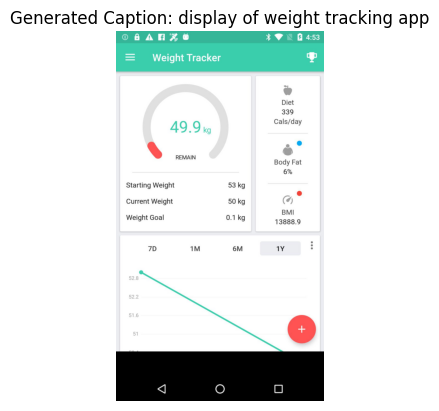

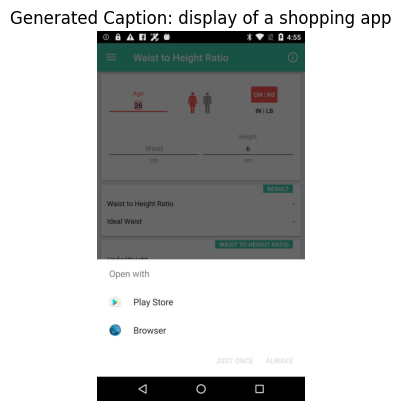

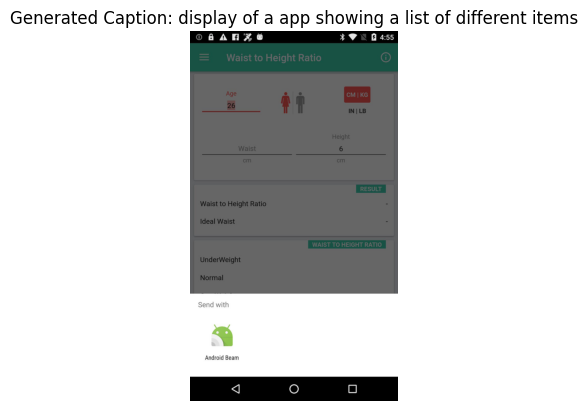

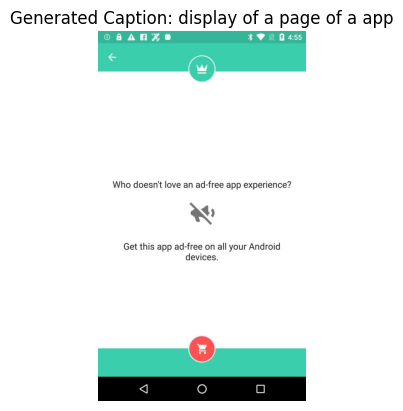

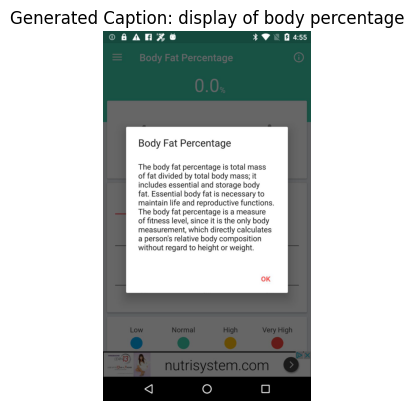

In [14]:
import matplotlib.pyplot as plt

num_examples = 5

for i in range(num_examples):

    sample = test_dataset[i]

    image = sample["image"]

    inputs = processor(image, return_tensors="pt")

    outputs = model.generate(**inputs)

    caption = processor.decode(outputs[0], skip_special_tokens=True)

    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Generated Caption: {caption}")
    plt.show()

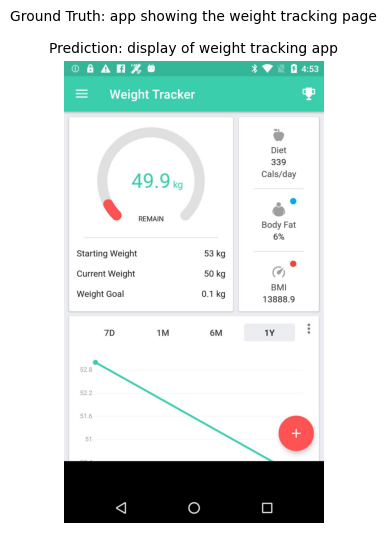

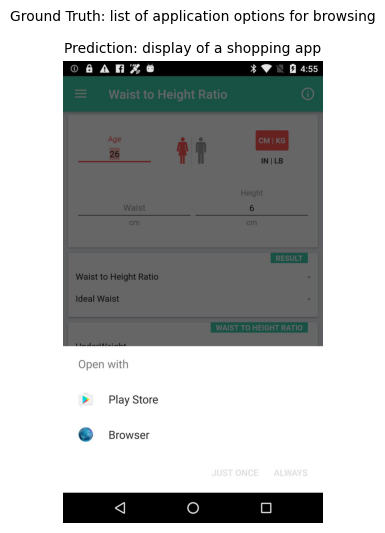

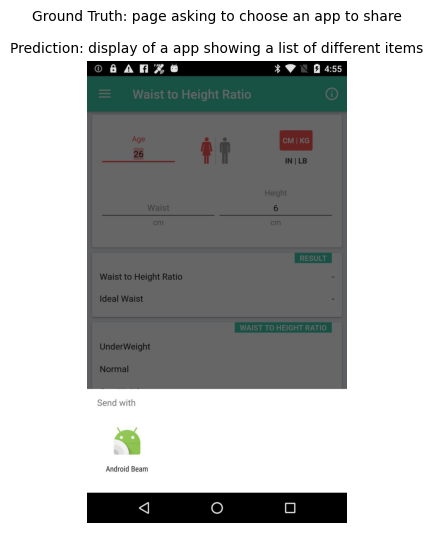

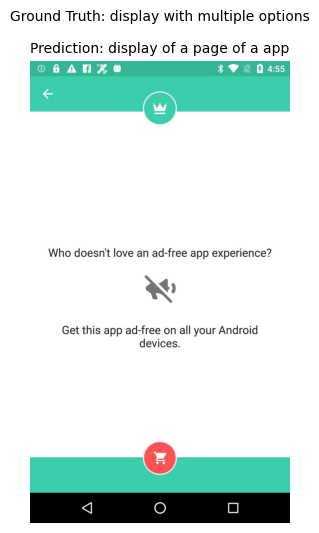

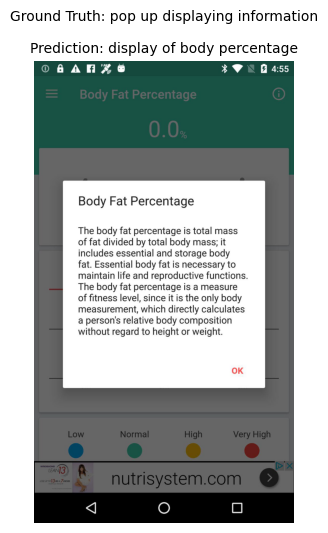

In [15]:
import matplotlib.pyplot as plt

num_examples = 5

for i in range(num_examples):

    sample = test_dataset[i]

    image = sample["image"]
    true_caption = sample["captions"][0]

    inputs = processor(image, return_tensors="pt")

    outputs = model.generate(**inputs)

    predicted_caption = processor.decode(outputs[0], skip_special_tokens=True)

    plt.figure(figsize=(6,6))
    plt.imshow(image)
    plt.axis("off")

    plt.title(
        f"Ground Truth: {true_caption}\n\nPrediction: {predicted_caption}",
        fontsize=10
    )

    plt.show()



The fine-tuned model is uploaded to Hugging Face Hub
for reproducibility and easy access.